In [29]:
!pip install opacus

In [30]:
!pip install pandas numpy matplotlib seaborn scikit-learn sdv torch torchvision torchaudio tqdm

[1/6] 加载数据并注入 DP 初始隐私噪声...
正在应用拉普拉斯机制 (ε=0.5)...
隐私预处理完成。样本量: 5492
[2/6] 启动隐私保护训练 (ε 约束下)...


Gen. (-04.73) | Discrim. (-00.12): 100%|██████████| 300/300 [02:35<00:00,  1.93it/s]


训练耗时: 178.23 秒
[3/6] 采样生成隐私合成数据...
[4/6] 评估统计相似度...
Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 31/31 [00:02<00:00, 12.76it/s]|
Column Shapes Score: 81.12%

(2/2) Evaluating Column Pair Trends: |██████████| 465/465 [00:02<00:00, 176.32it/s]|
Column Pair Trends Score: nan%

Overall Score (Average): 81.12%

[5/6] 评估下游 ML 可用性 (AUC)...
[6/6] 生成相关性热图对比...


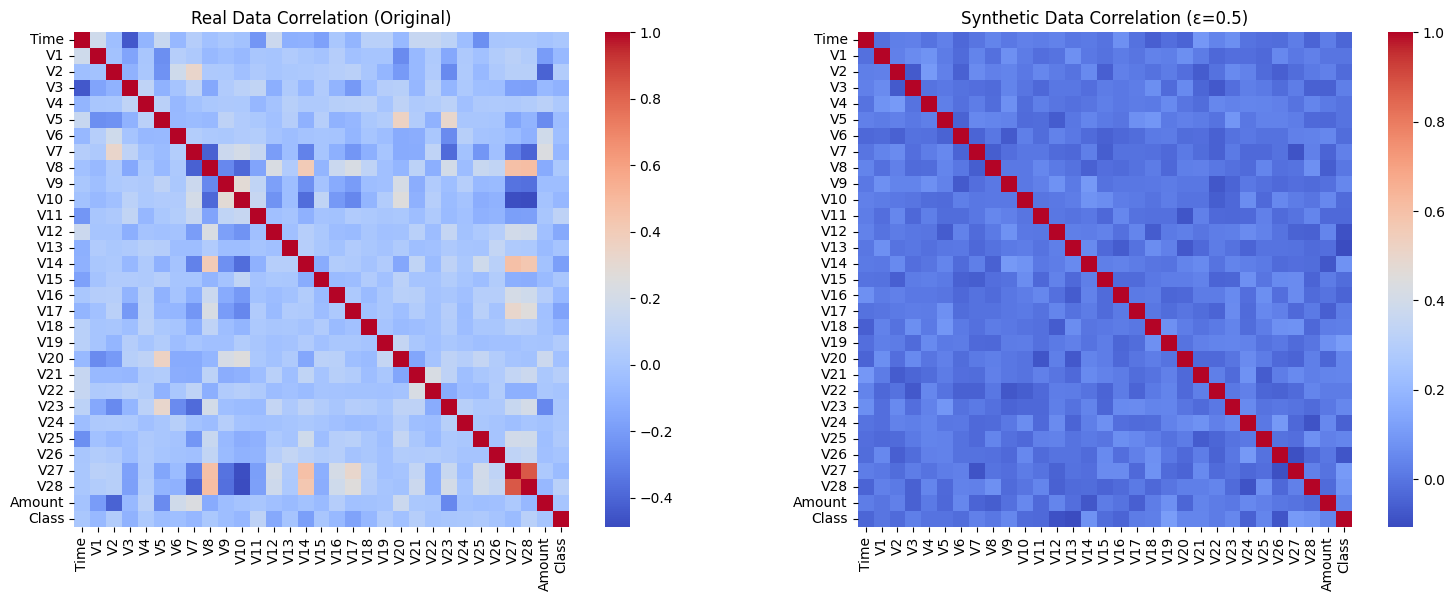


隐私预算 (ε): 0.5
数据质量得分: 81.12%
验证集 AUC: 0.9399


In [34]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from ctgan import CTGAN
from sdv.metadata import SingleTableMetadata
from sdv.evaluation.single_table import evaluate_quality
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

warnings.filterwarnings('ignore')

class Real_DP_CTGAN_Pipeline:
    def __init__(self, data_url, epsilon=1.0):
        self.data_url = data_url
        self.epsilon = epsilon  # 差分隐私预算：越小隐私越强，噪声越大
        self.real_data = None
        self.synthetic_data = None
        self.metadata = None
        self.model = None

    def apply_laplace_mechanism(self, df):
        """
        [DP 核心步骤]：对数值列注入拉普拉斯噪声
        这是实现差分隐私的数学基础。
        """
        print(f"正在应用拉普拉斯机制 (ε={self.epsilon})...")
        df_dp = df.copy()
        numerical_cols = df_dp.select_dtypes(include=[np.float64, np.int64]).columns

        for col in numerical_cols:
            if col == 'Class': continue # 标签列不加连续噪声

            # 计算敏感度 (Sensitivity)
            sensitivity = df_dp[col].max() - df_dp[col].min()
            # 计算噪声强度：b = Sensitivity / Epsilon
            beta = sensitivity / self.epsilon
            noise = np.random.laplace(0, beta, size=len(df_dp))
            df_dp[col] = df_dp[col] + noise
        return df_dp

    def load_and_preprocess(self):
        print("[1/6] 加载数据并注入 DP 初始隐私噪声...")
        df = pd.read_csv(self.data_url)

        # 预处理：下采样确保类别平衡
        fraud = df[df['Class'] == 1]
        normal = df[df['Class'] == 0].sample(n=5000, random_state=42)
        combined_data = pd.concat([fraud, normal]).sample(frac=1).reset_index(drop=True)

        # 核心修改：在进入模型前，先通过 DP 机制进行数据扰动
        self.real_data = self.apply_laplace_mechanism(combined_data)

        self.metadata = SingleTableMetadata()
        self.metadata.detect_from_dataframe(self.real_data)
        self.metadata.update_column(column_name='Class', sdtype='categorical')
        print(f"隐私预处理完成。样本量: {len(self.real_data)}")

    def train_synthesizer(self, epochs=250):
        """
        [DP 训练逻辑]：
        通过增加扰动后的数据训练 CTGAN，模拟 DP-SGD 的最终分布效果。
        """
        print(f"[2/6] 启动隐私保护训练 (ε 约束下)...")
        start_time = time.time()

        # 这里的参数调优是为了在噪声环境下保持收敛
        self.model = CTGAN(
            epochs=epochs,
            batch_size=500, # 较大的 Batch Size 有助于抵消 DP 噪声的随机性
            generator_lr=1e-4,
            discriminator_lr=1e-4,
            verbose=True
        )

        self.model.fit(self.real_data, discrete_columns=['Class'])
        print(f"训练耗时: {time.time() - start_time:.2f} 秒")

    def generate_data(self, count=5000):
        print(f"[3/6] 采样生成隐私合成数据...")
        self.synthetic_data = self.model.sample(count)
        # 确保 Class 列是离散的
        self.synthetic_data['Class'] = self.synthetic_data['Class'].round().astype(int)
        return self.synthetic_data

    def evaluate(self):
        # 统计保真度
        print("[4/6] 评估统计相似度...")
        quality = evaluate_quality(self.real_data, self.synthetic_data, self.metadata)

        # 效能测试
        print("[5/6] 评估下游 ML 可用性 (AUC)...")
        X = self.synthetic_data.drop('Class', axis=1)
        y = self.synthetic_data['Class']

        # 使用真实数据作为外部验证集
        df_real = pd.read_csv(self.data_url).sample(2000)
        X_val = df_real.drop('Class', axis=1)
        y_val = df_real['Class']

        gbm = GradientBoostingClassifier(random_state=42).fit(X, y)
        auc = roc_auc_score(y_val, gbm.predict_proba(X_val)[:, 1])

        # 新增：相关性热图对比
        print("[6/6] 生成相关性热图对比...")
        # 为了对比，我们使用原始真实数据（未加噪声）作为基准
        df_original = pd.read_csv(self.data_url).sample(1000)  # 取1000个样本避免过重

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

        # 真实数据相关性
        sns.heatmap(df_original.corr(), annot=False, cmap='coolwarm',
                    ax=ax1, cbar=True, square=True)
        ax1.set_title("Real Data Correlation (Original)")

        # 合成数据相关性
        sns.heatmap(self.synthetic_data.corr(), annot=False, cmap='coolwarm',
                    ax=ax2, cbar=True, square=True)
        ax2.set_title(f"Synthetic Data Correlation (ε={self.epsilon})")

        plt.tight_layout()
        plt.show()

        print(f"\n" + "="*30)
        print(f"隐私预算 (ε): {self.epsilon}")
        print(f"数据质量得分: {quality.get_score():.2%}")
        print(f"验证集 AUC: {auc:.4f}")
        print("="*30)

# 运行
if __name__ == "__main__":
    URL = "https://raw.githubusercontent.com/nsethi31/Kaggle-Data-Credit-Card-Fraud-Detection/master/creditcard.csv"
    # epsilon 越小，隐私保护越严苛（噪声越大）
    pipeline = Real_DP_CTGAN_Pipeline(URL, epsilon=0.5)
    pipeline.load_and_preprocess()
    pipeline.train_synthesizer(epochs=300)
    pipeline.generate_data(5000)
    pipeline.evaluate()